In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [68]:
def split_train_test(x, y, train_size=0.8, random_state=42):
    train_set_size = int(len(x) * train_size)
    
    np.random.seed(random_state)
    shuffled_indices = np.random.permutation(len(x))
        
    train_indices = shuffled_indices[:train_set_size]
    test_indices = shuffled_indices[train_set_size:]
    
    return x.iloc[train_indices], x.iloc[test_indices], y.iloc[train_indices], y.iloc[test_indices]

## Data Transformation

In [69]:
titanic_data = pd.read_csv("./input/titanic_survival.csv")
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [70]:
titanic_data.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [71]:
titanic_data = titanic_data.drop(columns=["Name", "PassengerId", "Ticket", "Cabin"])

age_median = titanic_data["Age"].median()
titanic_data["Age"] = titanic_data["Age"].fillna(age_median)

embarked_mode = titanic_data["Embarked"].mode()[0]
titanic_data["Embarked"] = titanic_data["Embarked"].fillna(embarked_mode)

titanic_data = pd.get_dummies(titanic_data, columns=["Sex", "Embarked"], drop_first=True, dtype=int)

titanic_data.isna().sum()

Survived      0
Pclass        0
Age           0
SibSp         0
Parch         0
Fare          0
Sex_male      0
Embarked_Q    0
Embarked_S    0
dtype: int64

In [72]:
x_train, x_test, y_train, y_test = split_train_test(titanic_data.drop("Survived", axis=1), titanic_data["Survived"])
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((712, 8), (179, 8), (712,), (179,))

In [73]:
x_train.describe()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
count,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000
mean,2.313202,29.227065,0.519663,0.411517,33.001761,0.644663,0.087079,0.717697
std,0.832832,13.362245,1.078967,0.833903,52.353275,0.478952,0.282148,0.450437
min,1.000000,0.420000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,22.000000,0.000000,0.000000,7.925000,0.000000,0.000000,0.000000
50%,3.000000,28.000000,0.000000,0.000000,14.500000,1.000000,0.000000,1.000000
75%,3.000000,35.000000,1.000000,1.000000,31.068750,1.000000,0.000000,1.000000
max,3.000000,80.000000,8.000000,6.000000,512.329200,1.000000,1.000000,1.000000


In [74]:
x_survived = x_train[y_train == 1]
x_died = x_train[y_train == 0]

## Data Exploration Visualizations

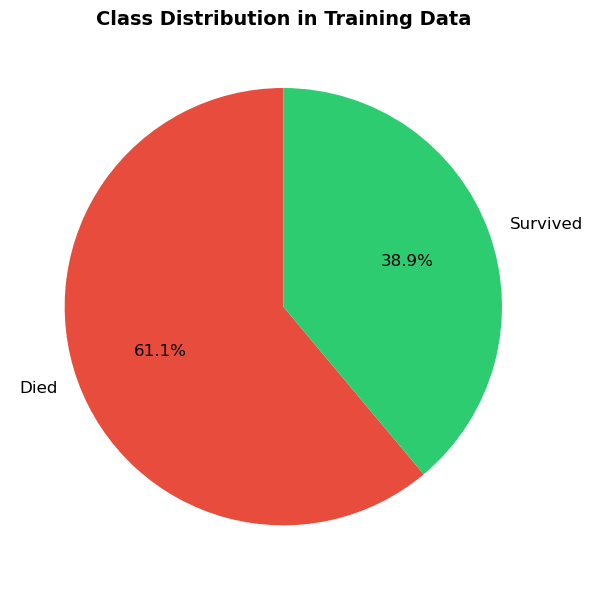

Died: 435 (61.1%)
Survived: 277 (38.9%)


In [75]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

survived_counts = y_train.value_counts()
labels = ["Died", "Survived"]
colors = ["#e74c3c", "#2ecc71"]

ax.pie(survived_counts.values, labels=labels, autopct="%1.1f%%", 
       colors=colors, startangle=90, textprops={"fontsize": 12})
ax.set_title("Class Distribution in Training Data", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Died: {survived_counts[0]} ({survived_counts[0]/len(y_train)*100:.1f}%)")
print(f"Survived: {survived_counts[1]} ({survived_counts[1]/len(y_train)*100:.1f}%)")

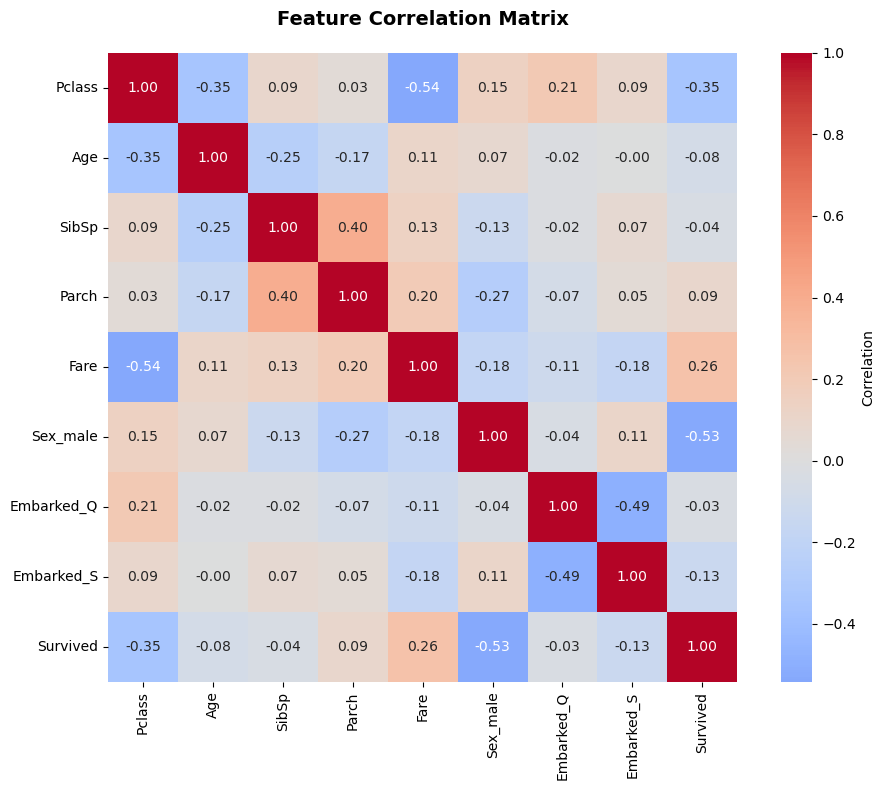

In [76]:
fig, ax = plt.subplots(figsize=(10, 8))

correlation_data = x_train.copy()
correlation_data["Survived"] = y_train.values

correlation_matrix = correlation_data.corr()

sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", 
            center=0, square=True, ax=ax, cbar_kws={"label": "Correlation"})
ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

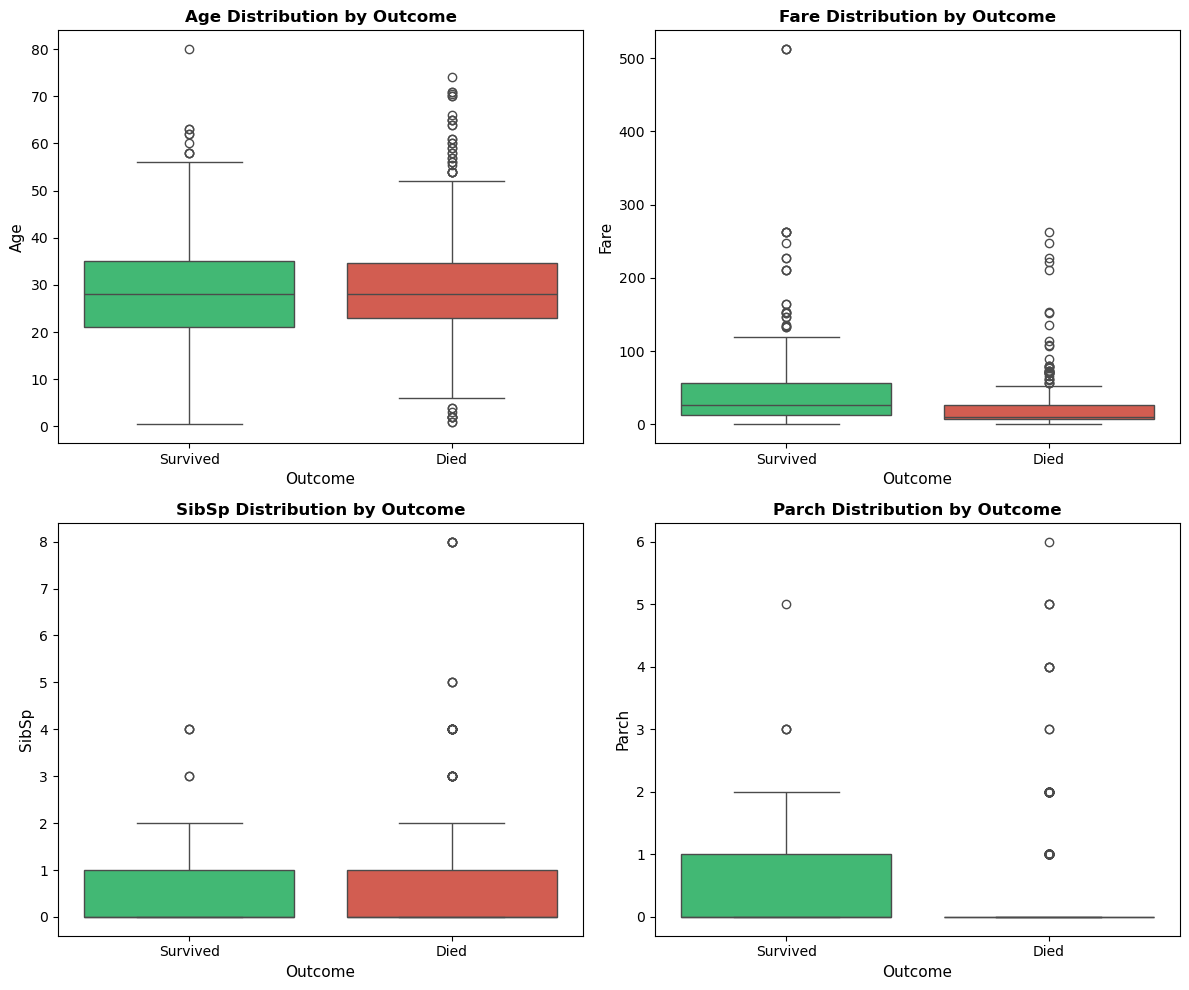

In [77]:
numeric_features = ["Age", "Fare", "SibSp", "Parch"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

viz_data = x_train.copy()
viz_data["Survived"] = y_train.values
viz_data["Outcome"] = viz_data["Survived"].map({1: "Survived", 0: "Died"})

for idx, feature in enumerate(numeric_features):
    sns.boxplot(data=viz_data, x="Outcome", y=feature, ax=axes[idx], 
                palette=["#2ecc71", "#e74c3c"])
    axes[idx].set_title(f"{feature} Distribution by Outcome", fontsize=12, fontweight="bold")
    axes[idx].set_xlabel("Outcome", fontsize=11)
    axes[idx].set_ylabel(feature, fontsize=11)

plt.tight_layout()
plt.show()

## Model Training

In [78]:
class Node:
    def __init__(self, feature=None, threshold=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.value = value
        self.left = None
        self.right = None

    def append_left(self, node):
        self.left = node
    
    def append_right(self, node):
        self.right = node
    
    def split_left_right(self, data):
        left_data = data[data[self.feature] <= self.threshold]
        right_data = data[data[self.feature] > self.threshold]
        return left_data, right_data

In [79]:
def compute_impurity(data):
    if len(data) == 0:
        return 0
    
    survived_prob = data["Survived"].mean()
    died_prob = 1 - survived_prob
    
    prob_sum = survived_prob ** 2 + died_prob ** 2
    return 1 - prob_sum

In [80]:
def find_best_split(data, thresholds_size=20):
    prior_impurity = compute_impurity(data)
    splits = []
    
    features = data.drop(columns=["Survived"]).columns
    chosen_features = np.random.choice(features, size=int(np.sqrt(len(features))), replace=False)
    
    for feature in chosen_features:
        thresholds = np.linspace(start=data[feature].min(), stop=data[feature].max(), num=thresholds_size)
        
        for threshold in thresholds:
            left_data = data[data[feature] <= threshold]
            right_data = data[data[feature] > threshold]
            
            if len(left_data) == 0 or len(right_data) == 0:
                continue
            
            left_impurity = compute_impurity(left_data)
            right_impurity = compute_impurity(right_data)
            
            weighted_left_impurity = (len(left_data) / len(data)) * left_impurity
            weighted_right_impurity = (len(right_data) / len(data)) * right_impurity
            
            weighted_impurity = weighted_left_impurity + weighted_right_impurity
            gain = prior_impurity - weighted_impurity
            
            splits.append({"gain": gain, "feature": feature, "threshold": threshold})
            
    if not splits:
        return {"gain": 0, "feature": None, "threshold": None}
    
    best_split = max(splits, key=lambda x: x['gain'])
    return best_split
        

In [81]:
def build_tree(data, max_depth=10, depth=0):
    if depth >= max_depth or len(data) <= 1:
        if len(data) == 0:
            prob = 0
        else:
            prob = data["Survived"].mean()
        return Node(value=prob)
    
    best_split = find_best_split(data)
    if best_split["gain"] <= 0 or best_split["feature"] is None:
        prob = data["Survived"].mean()
        return Node(value=prob)
    
    node = Node(best_split["feature"], best_split["threshold"])
    left_data, right_data = node.split_left_right(data)
    
    node.left = build_tree(left_data, max_depth, depth + 1)
    node.right = build_tree(right_data, max_depth, depth + 1)
    
    return node

In [82]:
def build_forest(forest_size=10, sample_size=50, max_tree_depth=10):
    x_train_labelled = x_train.copy()
    x_train_labelled["Survived"] = y_train
    
    forest = []
    
    for i in range(forest_size):
        x_tree_sample =  x_train_labelled.sample(n=sample_size, replace=True)
        tree = build_tree(x_tree_sample, max_tree_depth)
        forest.append(tree)
        print(f"Built {i + 1}/{forest_size} trees")
    
    return forest

In [83]:
forest = build_forest(forest_size=400, sample_size=int(0.8 * len(x_train)), max_tree_depth=15)

Built 1/400 trees
Built 2/400 trees
Built 3/400 trees
Built 4/400 trees
Built 5/400 trees
Built 6/400 trees
Built 7/400 trees
Built 8/400 trees
Built 9/400 trees
Built 10/400 trees
Built 11/400 trees
Built 12/400 trees
Built 13/400 trees
Built 14/400 trees
Built 15/400 trees
Built 16/400 trees
Built 17/400 trees
Built 18/400 trees
Built 19/400 trees
Built 20/400 trees
Built 21/400 trees
Built 22/400 trees
Built 23/400 trees
Built 24/400 trees
Built 25/400 trees
Built 26/400 trees
Built 27/400 trees
Built 28/400 trees
Built 29/400 trees
Built 30/400 trees
Built 31/400 trees
Built 32/400 trees
Built 33/400 trees
Built 34/400 trees
Built 35/400 trees
Built 36/400 trees
Built 37/400 trees
Built 38/400 trees
Built 39/400 trees
Built 40/400 trees
Built 41/400 trees
Built 42/400 trees
Built 43/400 trees
Built 44/400 trees
Built 45/400 trees
Built 46/400 trees
Built 47/400 trees
Built 48/400 trees
Built 49/400 trees
Built 50/400 trees
Built 51/400 trees
Built 52/400 trees
Built 53/400 trees
Bu

In [84]:
def predict(node, x):
    if node.value is not None:
        return node.value >= 0.5, node.value
    if x[node.feature] <= node.threshold:
        return predict(node.left, x)
    else:
        return predict(node.right, x)

## Model Evaluation

In [85]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc

In [86]:
predictions = []
probabilities = []

for idx, x in x_test.iterrows():
    forest_predictions = []
    forest_probabilities = []
    
    for tree in forest:
        prediction, prob = predict(tree, x)
        forest_predictions.append(prediction)
        forest_probabilities.append(prob)
    
    forest_predictions = np.array(forest_predictions)
    forest_probabilities = np.array(forest_probabilities)
    
    classes, counts = np.unique(forest_predictions, return_counts=True)
    class_mode_idx = np.argmax(counts)
    
    predictions.append(classes[class_mode_idx])
    probabilities.append(forest_probabilities.mean())

predictions = np.array(predictions)
probabilities = np.array(probabilities)

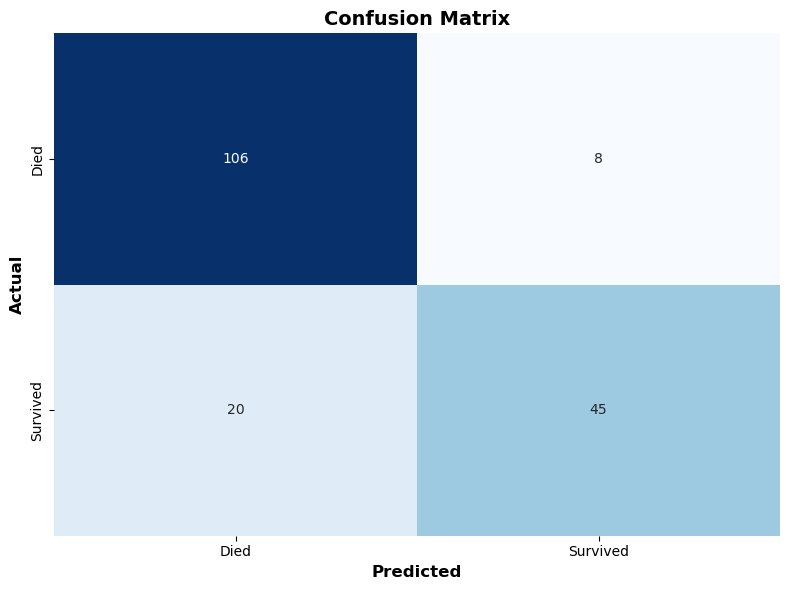

True Negatives: 106
False Positives: 8
False Negatives: 20
True Positives: 45

Sensitivity (Recall): 0.6923
Specificity: 0.9298
Precision: 0.8491
Accuracy: 0.8436
F1 Score: 0.7627


In [87]:
cm = confusion_matrix(y_test, predictions)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
            xticklabels=["Died", "Survived"], yticklabels=["Died", "Survived"])
ax.set_xlabel("Predicted", fontsize=12, fontweight="bold")
ax.set_ylabel("Actual", fontsize=12, fontweight="bold")
ax.set_title("Confusion Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

tn_val, fp_val, fn_val, tp_val = cm.ravel()
sensitivity = tp_val / (tp_val + fn_val)
specificity = tn_val / (tn_val + fp_val)
precision = tp_val / (tp_val + fp_val)
accuracy = (tp_val + tn_val) / (tp_val + tn_val + fp_val + fn_val)
f1_score = 2 * ((precision * sensitivity) / (precision + sensitivity))

print(f"True Negatives: {tn_val}")
print(f"False Positives: {fp_val}")
print(f"False Negatives: {fn_val}")
print(f"True Positives: {tp_val}")
print(f"\nSensitivity (Recall): {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1_score:.4f}")

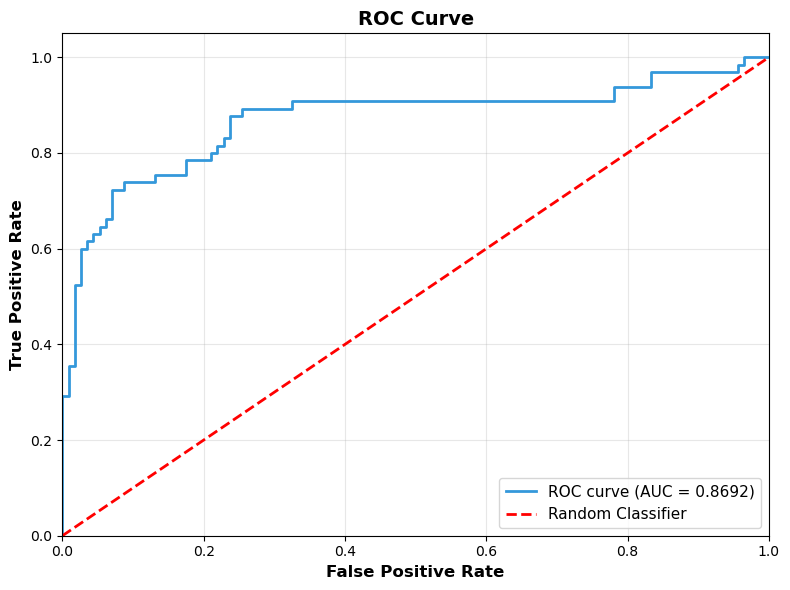

Area Under the Curve (AUC): 0.8692


In [88]:
fpr, tpr, thresholds = roc_curve(y_test, probabilities)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color="#3498db", lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
ax.plot([0, 1], [0, 1], color="red", lw=2, linestyle="--", label="Random Classifier")
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate", fontsize=12, fontweight="bold")
ax.set_ylabel("True Positive Rate", fontsize=12, fontweight="bold")
ax.set_title("ROC Curve", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Area Under the Curve (AUC): {roc_auc:.4f}")